# Repeated Measures ANOVA

## Overview
Repeated measures ANOVA is used when the same subjects (or experimental units) are measured multiple times — across time points, conditions, or treatments. Because measurements on the same subject are correlated, the standard ANOVA error term is inappropriate.

**Classical RM-ANOVA** (this notebook) vs **LMM approach** (see `lmm_basics.ipynb`):

| Aspect | Classical RM-ANOVA | LMM (lme4) |
|---|---|---|
| Correlation structure | Compound symmetry | Flexible (unstructured, AR1, etc.) |
| Missing data | Requires complete cases | Handles missing data via ML |
| Sphericity | Required; correctable | Not assumed |
| Software | `aov()`, `ez`, `afex` | `lme4::lmer()` |
| Common in | Older ecological/psych literature | Modern practice |

**Quinn & Keough (2002) ch. 10–11 / Underwood (1997) ch. 12.**

---

In [1]:
library(tidyverse); library(ez); library(afex); library(emmeans)
set.seed(21)
# Intertidal experiment: invertebrate abundance measured at
# 4 time points (Before, 1mo, 3mo, 6mo) on 15 permanent plots
n_subjects <- 15
time_pts   <- c("Before","1mo","3mo","6mo")
dat <- expand.grid(
  subject = factor(1:n_subjects),
  time    = factor(time_pts, levels=time_pts)
)
# Simulate: abundance decreases then recovers; subject random effect
subj_effect <- rep(rnorm(n_subjects, 0, 3), times=4)
time_means  <- c(20, 15, 17, 19)
dat$abundance <- time_means[as.integer(dat$time)] +
                 subj_effect + rnorm(nrow(dat), 0, 2.5)
dat$abundance <- pmax(dat$abundance, 0)
cat("Repeated measures dataset:\n"); print(head(dat, 8))
cat("\nDesign: 1 within-subjects factor (Time, 4 levels)\n")

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'ez' was built under R version 4.4.3"
Registered S3 method overwritten by 'lme4':
  method           from
 

Repeated measures dataset:
  subject   time abundance
1       1 Before  26.15858
2       2 Before  23.21432
3       3 Before  28.04374
4       4 Before  14.22439
5       5 Before  25.52794
6       6 Before  22.28189
7       7 Before  15.38129
8       8 Before  14.61507

Design: 1 within-subjects factor (Time, 4 levels)


---
## Sphericity: Mauchly's test and corrections

In [2]:
# Classical RM-ANOVA with ez package
m_rm <- ez::ezANOVA(
  data      = dat,
  dv        = abundance,
  wid       = subject,
  within    = time,
  type      = 3,
  return_aov= TRUE
)
cat("RM-ANOVA results:\n"); print(m_rm$ANOVA)
cat("\nMauchly's Test of Sphericity:\n"); print(m_rm$`Mauchly's Test for Sphericity`)
cat("\nSphericity corrections:\n"); print(m_rm$`Sphericity Corrections`)

cat("\nInterpretation:\n")
cat("  p(Mauchly) > 0.05 → sphericity not violated → use uncorrected F\n")
cat("  p(Mauchly) < 0.05 → use GGe (Greenhouse-Geisser) or HFe (Huynh-Feldt)\n")
cat("  GGe conservative; HFe less so; GGe preferred when GGe < 0.75\n")

RM-ANOVA results:
  Effect DFn DFd        F          p p<.05        ges
2   time   3  42 4.788498 0.00585831     * 0.09549064

Mauchly's Test of Sphericity:
  Effect         W          p p<.05
2   time 0.3179746 0.01259602     *

Sphericity corrections:
  Effect       GGe      p[GG] p[GG]<.05       HFe       p[HF] p[HF]<.05
2   time 0.7236209 0.01363935         * 0.8612333 0.008937189         *

Interpretation:
  p(Mauchly) > 0.05 → sphericity not violated → use uncorrected F
  p(Mauchly) < 0.05 → use GGe (Greenhouse-Geisser) or HFe (Huynh-Feldt)
  GGe conservative; HFe less so; GGe preferred when GGe < 0.75


Estimated marginal means by time:
 time   emmean   SE   df lower.CL upper.CL
 Before   19.9 1.14 27.5     17.5     22.2
 1mo      16.1 1.14 27.5     13.7     18.4
 3mo      17.9 1.14 27.5     15.6     20.3
 6mo      18.6 1.14 27.5     16.3     21.0

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

Pairwise comparisons (Bonferroni):
 contrast     estimate   SE df t.ratio p.value
 Before - 1mo    3.824 1.03 42   3.704  0.0037
 Before - 3mo    1.939 1.03 42   1.879  0.4034
 Before - 6mo    1.245 1.03 42   1.206  1.0000
 1mo - 3mo      -1.884 1.03 42  -1.826  0.4502
 1mo - 6mo      -2.578 1.03 42  -2.498  0.0990
 3mo - 6mo      -0.694 1.03 42  -0.672  1.0000

Degrees-of-freedom method: kenward-roger 
P value adjustment: bonferroni method for 6 tests 

Repeated measures ANOVA table:

Error: subject
          Df Sum Sq Mean Sq F value Pr(>F)
Residuals 14  751.7   53.69               

Error: subject:time
          Df Sum Sq Mean Sq F value  Pr(>F)   
time       3  114.

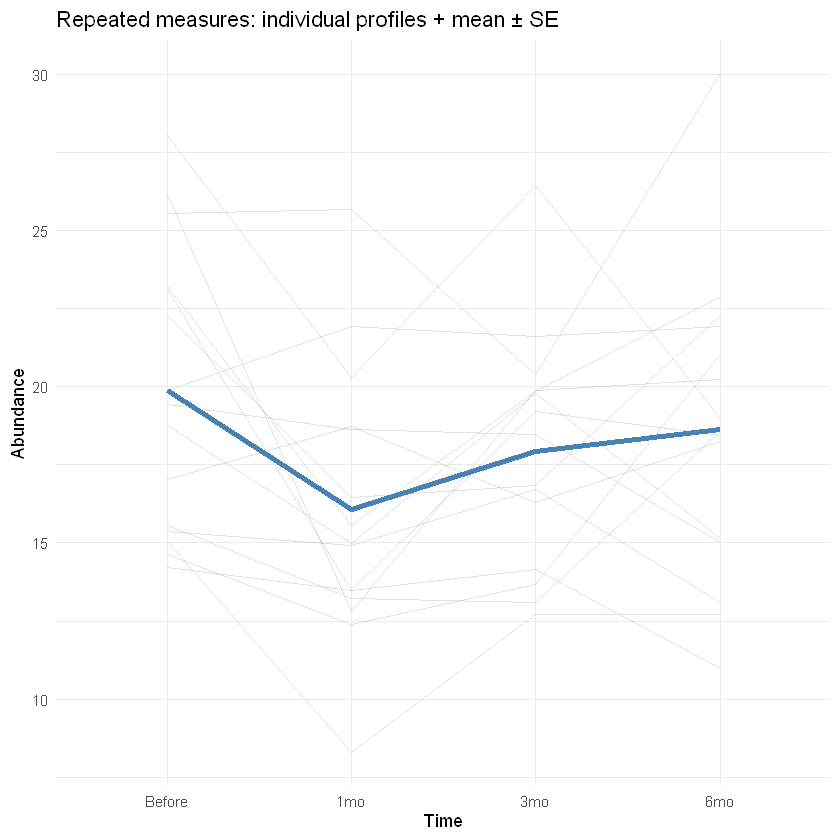

In [6]:
library(lme4)
library(emmeans)

# Fit with lmer instead — emmeans works natively with this
m_rm_lmer <- lmer(abundance ~ time + (1 | subject), data = dat)

# emmeans works directly, no special arguments needed
em <- emmeans(m_rm_lmer, ~ time)
cat("Estimated marginal means by time:\n")
print(em)

cat("\nPairwise comparisons (Bonferroni):\n")
print(pairs(em, adjust = "bonferroni"))

# Keep aov version for the ANOVA table if needed
m_rm_aov <- aov(abundance ~ time + Error(subject/time), data = dat)
cat("\nRepeated measures ANOVA table:\n")
print(summary(m_rm_aov))

# Profile plot
ggplot(dat, aes(time, abundance, group = subject)) +
  geom_line(alpha = 0.3, colour = "grey60") +
  stat_summary(aes(group = 1), fun = mean, geom = "line",
               colour = "steelblue", linewidth = 1.5) +
  stat_summary(fun.data = mean_se, geom = "errorbar",
               colour = "steelblue", width = 0.2) +
  labs(title = "Repeated measures: individual profiles + mean ± SE",
       x = "Time", y = "Abundance") +
  theme_minimal()

In [7]:
# Modern alternative: LMM with lme4
library(lme4); library(lmerTest)
m_lmm <- lmer(abundance ~ time + (1|subject), data=dat)
cat("LMM equivalent (compound symmetry):\n")
print(anova(m_lmm))
cat("\nLMM vs RM-ANOVA: LMM is preferable when:\n")
cat("  - Missing data present (LMM uses all available data via ML)\n")
cat("  - Sphericity is violated (LMM can model complex covariance structures)\n")
cat("  - Unequal time intervals or continuous time variable\n")


Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step




LMM equivalent (compound symmetry):
Type III Analysis of Variance Table with Satterthwaite's method
     Sum Sq Mean Sq NumDF DenDF F value   Pr(>F)   
time 114.79  38.263     3    42  4.7885 0.005858 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

LMM vs RM-ANOVA: LMM is preferable when:
  - Missing data present (LMM uses all available data via ML)
  - Sphericity is violated (LMM can model complex covariance structures)
  - Unequal time intervals or continuous time variable


---
## Common Pitfalls

**1. Not testing sphericity before reporting uncorrected F**
The sphericity assumption (equal variances of all pairwise difference scores) is frequently violated in ecological repeated measures data. Always report Mauchly's test and, if violated (p < 0.05), apply Greenhouse-Geisser or Huynh-Feldt correction. Modern practice often applies GGe correction by default.

**2. Using standard one-way ANOVA ignoring the within-subjects structure**
Treating repeated measures as independent observations inflates degrees of freedom and underestimates the error term, producing anti-conservative tests. The within-subjects correlation must be removed from the error term.

**3. Dropping subjects with any missing time points**
Classical RM-ANOVA in `aov()` requires a complete balanced design — subjects with missing data are excluded. This can substantially reduce power. Use `lme4::lmer()` which handles missing data via maximum likelihood and retains all available observations.

**4. Confusing within-subjects and between-subjects factors**
A within-subjects (repeated measures) factor has each subject measured at all levels. A between-subjects factor assigns each subject to only one level. Mixed designs have both. Using the wrong error term for a factor produces incorrect F-ratios.

**5. Not accounting for time as ordered when doing post-hoc tests**
For time-series repeated measures, pairwise comparisons treat all pairs equally. If a gradient over time is hypothesised, polynomial contrasts (linear, quadratic) are more powerful and appropriate.

**6. Ignoring individual subject profiles in interpretation**
The mean profile can mask important individual variation — some subjects may increase while others decrease, making the mean appear flat. Always plot individual trajectories alongside the mean.


---
*r_methods_library - Samantha McGarrigle*